In [1]:
from lab_temp_monitor.temp_data_remote_copy import PiFileTransfer

In [8]:
from lab_temp_monitor.remote_pi_config import pi_config

RPI = PiFileTransfer(pi_config)

Connection to 100.88.110.107 successful!


In [11]:
RPI.sftp.listdir(RPI.remote_dir)

['2026_04_06_to_2026_04_12.csv', '2026_03_30_to_2026_04_05.csv']

In [5]:
# RPI.local_root = 

RPI.sync_files()

Saving to: /Users/FGB/Projects/lab_data_logging/temp_logging/2026
-> 2026_03_30_to_2026_04_05.csv: Transfer complete.


/var/folders/px/k0r95vj55f3b9_cmpdssstsm0000gn/T/ipykernel_2130/2836163535.py:11: UserWarning: Parsing dates in %d/%m/%Y %H:%M:%S format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['Timestamp'] = pd.to_datetime(df.iloc[:, 0].astype(str) + ' ' + df.iloc[:, 1].astype(str))


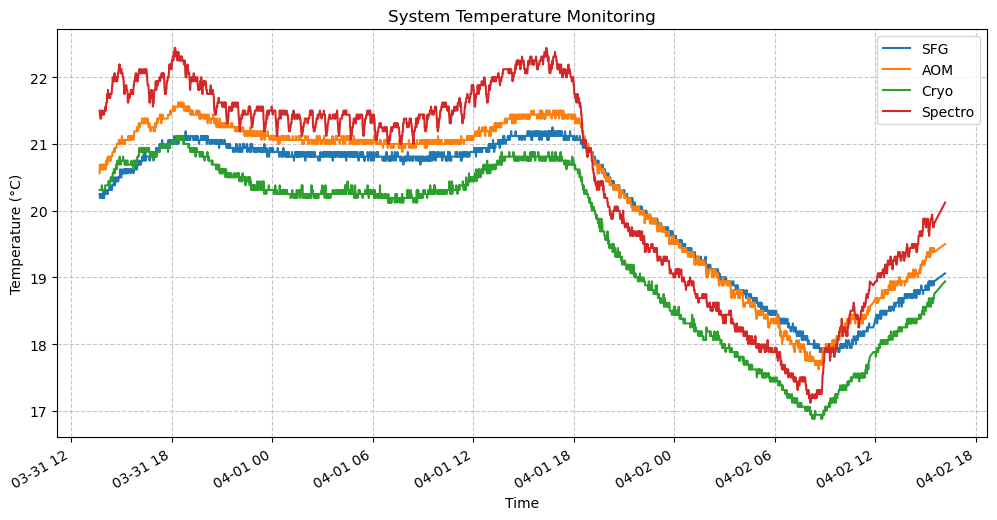

In [10]:
import pandas as pd
import matplotlib.pyplot as plt

data_path = r'/Users/FGB/Projects/lab_data_logging/temp_logging/2026/2026_03_30_to_2026_04_05.csv'

# Load your data (example)
df = pd.read_csv(data_path)

# Combine the first two columns into a single 'Timestamp'
# We use .astype(str) to ensure they are treated as text during concatenation
df['Timestamp'] = pd.to_datetime(df.iloc[:, 0].astype(str) + ' ' + df.iloc[:, 1].astype(str))

# Set the Timestamp as the index for easier plotting
df.set_index('Timestamp', inplace=True)

# Create the plot
plt.figure(figsize=(12, 6))

# Plot each column
plt.plot(df.index, df['SFG (C)'], label='SFG')
plt.plot(df.index, df['AOM (C)'], label='AOM')
plt.plot(df.index, df['Cryo (C)'], label='Cryo')
plt.plot(df.index, df['Spectro (C)'], label='Spectro')

# Formatting
plt.title('System Temperature Monitoring')
plt.xlabel('Time')
plt.ylabel('Temperature (°C)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

# Auto-format the dates on the x-axis to prevent overlapping
plt.gcf().autofmt_xdate()

plt.show()

In [23]:
df

,Date (Y/M/D),Time (H:M:S),AOM (C),SFG (C),Spectro (C),Cryo (C)
Timestamp,,,,,,
2026-03-31 13:42:05,31/03/2026,13:42:05,20.56,20.25,21.50,20.31
2026-03-31 13:43:04,31/03/2026,13:43:04,20.69,20.19,21.44,20.31
2026-03-31 13:44:05,31/03/2026,13:44:05,20.62,20.25,21.44,20.31
2026-03-31 13:45:04,31/03/2026,13:45:04,20.62,20.25,21.38,20.31
2026-03-31 13:46:04,31/03/2026,13:46:04,20.69,20.25,21.38,20.31
...,...,...,...,...,...,...
2026-04-02 15:28:04,02/04/2026,15:28:04,19.38,18.94,19.75,18.69
2026-04-02 15:29:04,02/04/2026,15:29:04,19.44,18.88,19.75,18.69
2026-04-02 15:30:05,02/04/2026,15:30:05,19.38,18.94,19.81,18.69
